<a href="https://colab.research.google.com/github/ivan-block/Traffic/blob/main/up2561204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras import layers
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D

In [59]:
from google.colab import drive

In [60]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [61]:
! ls gdrive/MyDrive

'20c4e246-257e-46e9-afd2-a60e1240afab (1).jpeg'
 20c4e246-257e-46e9-afd2-a60e1240afab.jpeg
 2f3d1103-f7e3-4886-822b-d51054790010.jpeg
 b13e19d9-6fb2-4d59-a18e-f01c880b07cc.jpeg
'C.ENG SOP.gdoc'
'Children act presentation.gslides'
'Colab Notebooks'
'Critically Analysing the Relationship Between Social Policy, the Care Act 2014 and Social Work Practice:.gdoc'
'Data visualisation From Questions to Understanding.gslides'
'ESOP APPLICATION.gdoc'
'ETHZ ZURICH PRE-PROPOSAL.gdoc'
 flower_photos.zip
'Good chart bad chart (1).gdoc'
'Good chart bad chart.gdoc'
 IMG_0469.png
'Ivan Agwuye CV.gdoc'
' key statutes,social policy,and social work practice.gdoc'
'PERSONAL STATEMENT (1).gdoc'
'PERSONAL STATEMENT (2).gdoc'
'PERSONAL STATEMENT (3).gdoc'
'PERSONAL STATEMENT.gdoc'
'Professional Reference Letter.gdoc'
'Tableau logbook (1).gdoc'
'Tableau logbook.gdoc'
 test_set.zip
 traffic.zip
'Untitled document (1).gdoc'
'Untitled document (2).gdoc'
'Untitled document (3).gdoc'
'Untitled document.gdoc'
'Untit

In [62]:
!unzip -o gdrive/MyDrive/traffic.zip

Archive:  gdrive/MyDrive/traffic.zip
  inflating: traffic/Red/000803.jpg  
  inflating: traffic/Red/000806.jpg  
  inflating: traffic/Red/000856.jpg  
  inflating: traffic/Red/000865.jpg  
  inflating: traffic/Red/000867.jpg  
  inflating: traffic/Red/000873.jpg  
  inflating: traffic/Red/000878.jpg  
  inflating: traffic/Red/000879.jpg  
  inflating: traffic/Red/000882.jpg  
  inflating: traffic/Red/000892.jpg  
  inflating: traffic/Red/000896.jpg  
  inflating: traffic/Red/000903.jpg  
  inflating: traffic/Red/000905.jpg  
  inflating: traffic/Red/000911.jpg  
  inflating: traffic/Red/000916.jpg  
  inflating: traffic/Red/000920.jpg  
  inflating: traffic/Red/000928.jpg  
  inflating: traffic/Red/000951.jpg  
  inflating: traffic/Red/002579.jpg  
  inflating: traffic/Red/000000.jpg  
  inflating: traffic/Red/000001.jpg  
  inflating: traffic/Red/000002.jpg  
  inflating: traffic/Red/000008.jpg  
  inflating: traffic/Red/000014.jpg  
  inflating: traffic/Red/000023.jpg  
  inflating: 

In [63]:
X=[]
Z=[]
IMG_SIZE=256
GREEN_DIR='/content/traffic/Green'
RED_DIR='/content/traffic/Red'

In [64]:
def assign_label(img,traffic_sign):
    return traffic_sign

In [65]:
def make_train_data(traffic_sign,DIR):
    for img in os.listdir(DIR):
        print('print DIR:',DIR)
        #print('print listdir :',os.listdir(DIR))
        label=assign_label(img,traffic_sign)
        path = os.path.join(DIR,img)
        print(path)
        img = cv2.imread(path,cv2.IMREAD_COLOR)
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        X.append(np.array(img))
        Z.append(str(label))
        print(Z)

In [66]:
make_train_data('Green',GREEN_DIR)

print DIR: /content/traffic/Green
/content/traffic/Green/000175.jpg
['Green']
print DIR: /content/traffic/Green
/content/traffic/Green/000503.jpg
['Green', 'Green']
print DIR: /content/traffic/Green
/content/traffic/Green/000406.jpg
['Green', 'Green', 'Green']
print DIR: /content/traffic/Green
/content/traffic/Green/000162.jpg
['Green', 'Green', 'Green', 'Green']
print DIR: /content/traffic/Green
/content/traffic/Green/000634.jpg
['Green', 'Green', 'Green', 'Green', 'Green']
print DIR: /content/traffic/Green
/content/traffic/Green/000657.jpg
['Green', 'Green', 'Green', 'Green', 'Green', 'Green']
print DIR: /content/traffic/Green
/content/traffic/Green/000336.jpg
['Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green']
print DIR: /content/traffic/Green
/content/traffic/Green/000502.jpg
['Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green']
print DIR: /content/traffic/Green
/content/traffic/Green/000129.jpg
['Green', 'Green', 'Green', 'Green', 'Green', 'Green', '

In [67]:
make_train_data('Red',RED_DIR)

print DIR: /content/traffic/Red
/content/traffic/Red/000093.jpg
['Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Red']
print DIR: /content/traffic/

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

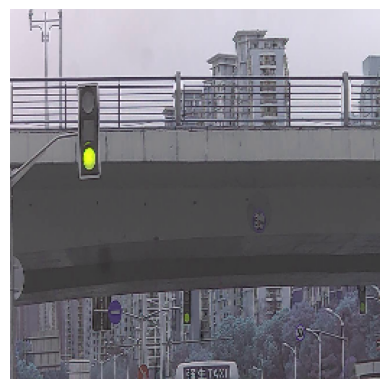

In [68]:
plt.imshow(X[1])
plt.axis('off')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

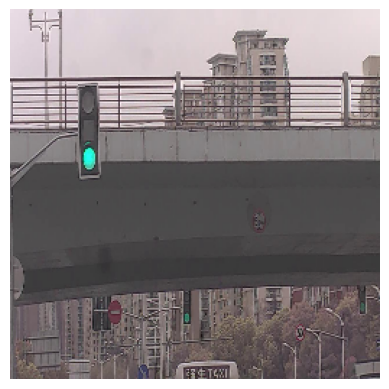

In [69]:
plt.imshow(X[1][:,:,::-1])
plt.axis('off')

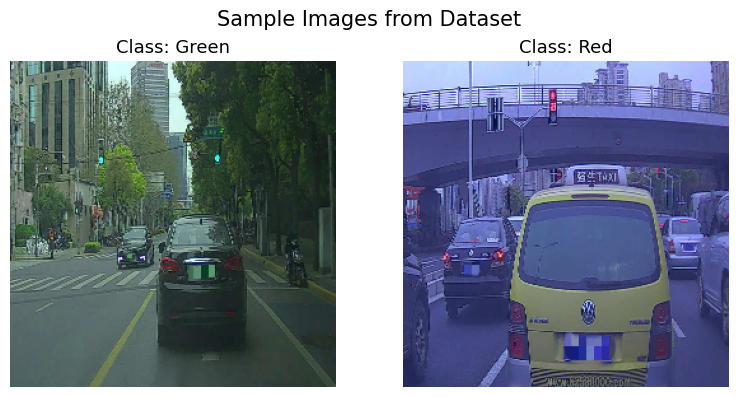

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
green_idx = Z.index('Green')
red_idx   = Z.index('Red')
for ax, idx, label in zip(axes, [green_idx, red_idx], ['Green', 'Red']):
    ax.imshow(X[idx][:,:,::-1]) # Convert BGR to RGB for matplotlib
    ax.set_title(f'Class: {label}', fontsize=13)
    ax.axis('off')
plt.suptitle('Sample Images from Dataset', fontsize=15)
plt.tight_layout()
plt.show()

In [71]:
le=LabelEncoder()
print(Z)
Y=le.fit_transform(Z)
Y=to_categorical(Y,2)
print(Y)
X=np.array(X)
X=X/255

['Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Green', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red', '

In [72]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.20,random_state=42, stratify=Y)
x_train.shape
x_test.shape

(40, 256, 256, 3)

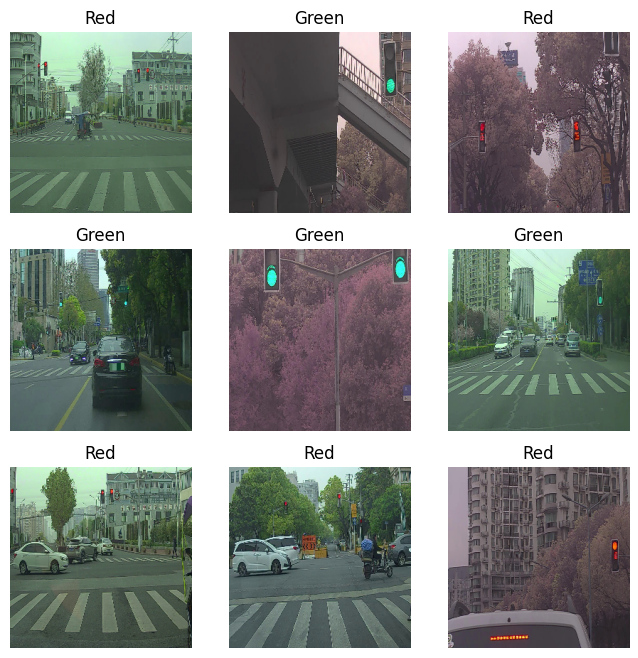

In [73]:
plt.figure(figsize=(8, 8))

# Define class_names using the fitted LabelEncoder
class_names = le.classes_

# Create a tf.data.Dataset named 'traffic' from the training data
# Assume we want to display a batch of 9 images
traffic = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(9)

for images, labels in traffic.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Scale images back to 0-255 for uint8 display, as X was divided by 255
        plt.imshow((images[i].numpy() * 255).astype("uint8")[:,:,::-1])
        # Labels are one-hot encoded, so use argmax to get the class index
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

In [74]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(256,
                                  256,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [75]:
model = Sequential([
  data_augmentation,
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(96, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(96, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(512, activation='relu'),
  layers.Dense(2, activation = "softmax")
])


In [76]:
model.compile(optimizer='Adam',loss='CategoricalCrossentropy',metrics=['accuracy'])

In [77]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 24576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,583,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,742,274 (48.61 MB)

 Trainable params: 12,742,274 (48.61 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
History = model.fit(x_train,y_train,  epochs = 50, validation_split=0.1)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.4792 - loss: 1.0637 - val_accuracy: 0.6875 - val_loss: 0.6724
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5208 - loss: 0.7007 - val_accuracy: 0.3125 - val_loss: 0.7052
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.4861 - loss: 0.6958 - val_accuracy: 0.6875 - val_loss: 0.6848
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5208 - loss: 0.6909 - val_accuracy: 0.3125 - val_loss: 0.7378
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5208 - loss: 0.6913 - val_accuracy: 0.3125 - val_loss: 0.7288
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5208 - loss: 0.6915 - val_accuracy: 0.3125 - val_loss: 0.6980
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.5208 - loss: 0.6865 - val_accuracy: 0.3125 - val_loss: 0.7783
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.5347 - loss: 0.6653 - val_accuracy: 0.3125 - val_loss: 1.04

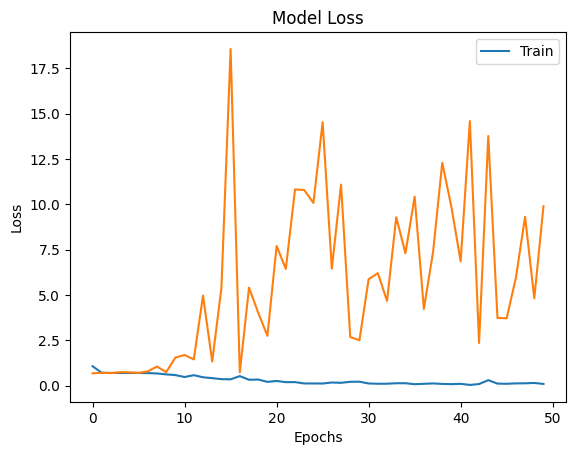

In [79]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'],label='Validation loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train'])
plt.show()

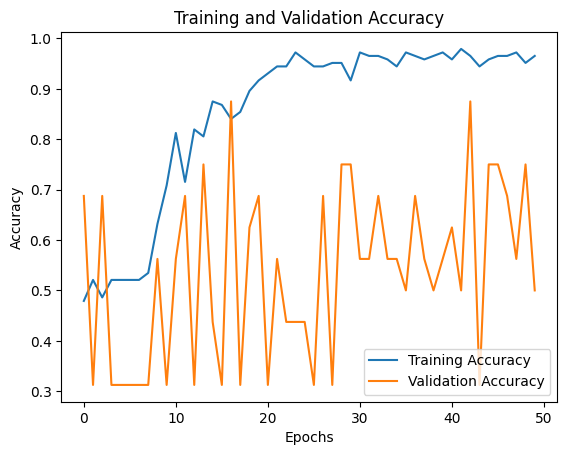

In [80]:
plt.plot(History.history['accuracy'],label='Training Accuracy')
plt.plot(History.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7250 - loss: 3.6851
[3.685098648071289, 0.7250000238418579]


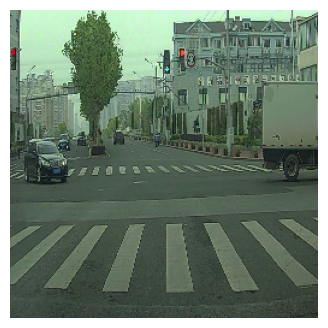

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
predicted label is  1


In [81]:
loss_metric=model.evaluate(x_test,y_test)
print(loss_metric)
image_number =12
plt.figure(figsize=(4,4))
plt.imshow(x_test[image_number][:,:,::-1])
plt.axis('off')
plt.show()
predicted_label = pred = model.predict(x_test[image_number].reshape(1, 256, 256, 3))
print('predicted label is ',predicted_label.argmax())

In [82]:
loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7250 - loss: 3.6851
Test Accuracy: 72.50%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


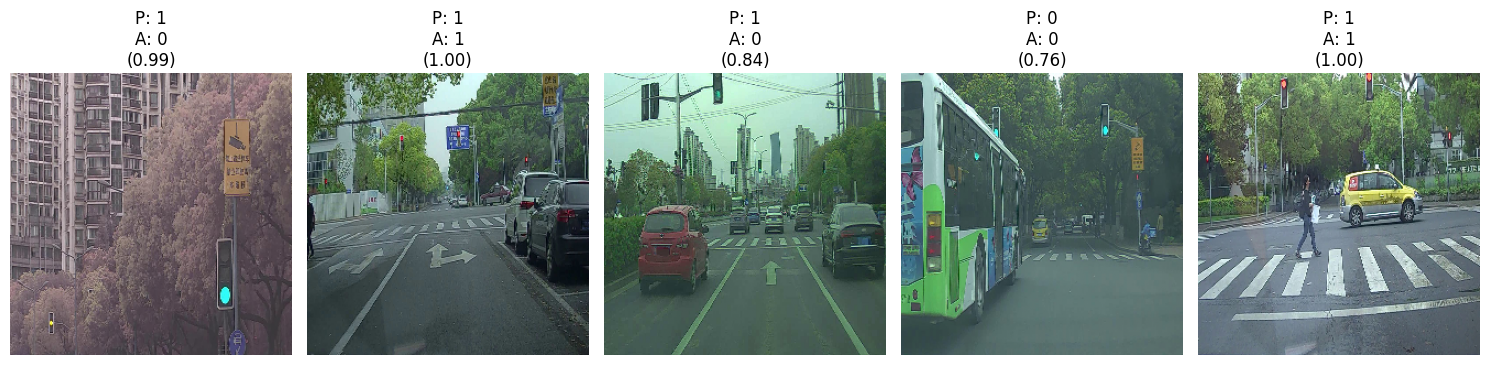

In [83]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Select 5 random indices
random_indices = random.sample(range(len(x_test)), 5)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(random_indices):
    img = x_test[idx]

    # Prediction
    pred = model.predict(img.reshape(1,256,256,3))
    predicted_label = np.argmax(pred)
    actual_label = np.argmax(y_test[idx])
    confidence = np.max(pred)

    # Plot
    plt.subplot(1, 5, i+1)
    plt.imshow(img[:,:,::-1])
    plt.title(f"P: {predicted_label}\nA: {actual_label}\n({confidence:.2f})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [84]:
!pip install ultralytics

from ultralytics import YOLO
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [85]:
# Load pretrained YOLO model
yolo_model = YOLO("yolov8n.pt")  # lightweight model

In [88]:
def detect_and_crop(image):
    results= yolo_model.predict(source=image, classes=[9])

    for r in results:
        boxes = r.boxes.xyxy.cpu().numpy()

        if len(boxes) == 0:
            return image  # fallback if nothing detected

        # Take first detected object
        x1, y1, x2, y2 = boxes[0].astype(int)
        cropped = image[y1:y2, x1:x2]

        return cropped

    return image

In [89]:
X_processed = []

for img in X:  # your original dataset
    img_uint8 = (img * 255).astype(np.uint8)
    cropped = detect_and_crop(img_uint8)

    resized = cv2.resize(cropped, (256, 256))
    normalized = resized / 255.0

    X_processed.append(normalized)

X_processed = np.array(X_processed)


0: 640x640 2 traffic lights, 8.4ms
Speed: 2.4ms preprocess, 8.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 traffic light, 7.9ms
Speed: 2.2ms preprocess, 7.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 traffic light, 7.7ms
Speed: 3.0ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 traffic lights, 7.6ms
Speed: 2.6ms preprocess, 7.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 traffic lights, 8.1ms
Speed: 3.0ms preprocess, 8.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 traffic light, 9.7ms
Speed: 2.9ms preprocess, 9.7ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 traffic lights, 7.9ms
Speed: 4.5ms preprocess, 7.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 traffic lights, 7.6ms
Speed: 2.9ms preprocess, 7.6ms inference, 1

In [91]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_processed, Y, test_size=0.2, random_state=42
)

In [92]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=16
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8562 - loss: 0.6638 - val_accuracy: 0.8250 - val_loss: 0.4003
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9062 - loss: 0.3660 - val_accuracy: 0.9000 - val_loss: 0.3115
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8938 - loss: 0.3235 - val_accuracy: 0.8750 - val_loss: 0.3202
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9312 - loss: 0.2292 - val_accuracy: 0.8500 - val_loss: 0.3509
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9312 - loss: 0.2684 - val_accuracy: 0.9000 - val_loss: 0.3093
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9187 - loss: 0.2629 - val_accuracy: 0.8750 - val_loss: 0.3331
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9187 - loss: 0.2078 - val_accuracy: 0.8750 - val_loss: 0.3132
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9375 - loss: 0.2084 - val_accuracy: 0.8750 - v

In [93]:
loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy after YOLO preprocessing: {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8250 - loss: 0.3653
Test Accuracy after YOLO preprocessing: 82.50%
